# CANDLE/FCIS - Causal Inference (Do-Calculus)

Estimate causal effects using Pearl's do-calculus.

**Key Question**: What is the effect of `do(Sentiment = +1.5)` on stock returns?

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from causal_inference import CausalInferenceEngine
from visualization import CANDLEVisualizer

viz = CANDLEVisualizer('../results/figures')
print(viz)

In [2]:
# Load merged data
data = pd.read_csv('../data/processed/merged_data.csv', index_col=0, parse_dates=True)
print(f"✓ Data loaded: {data.shape}")
print(f"  Variables: {list(data.columns)[:5]}... (total {len(data.columns)})")

# Load causal graph
import pickle
import os

pkl_path = '../data/processed/causal_graph.pkl'
graphml_path = '../data/processed/causal_graph.graphml'

print(f"\nLooking for graph files...")
print(f"  {pkl_path}: {'EXISTS' if os.path.exists(pkl_path) else 'NOT FOUND'}")
print(f"  {graphml_path}: {'EXISTS' if os.path.exists(graphml_path) else 'NOT FOUND'}")

graph = None

# Try pickle first
if os.path.exists(pkl_path):
    print(f"\nLoading from pickle...")
    try:
        with open(pkl_path, 'rb') as f:
            graph = pickle.load(f)
        print(f"✓ SUCCESS: {len(graph.nodes)} nodes, {len(graph.edges)} edges")
    except Exception as e:
        print(f"✗ Pickle load failed: {type(e).__name__}: {str(e)[:100]}")

# Try GraphML if pickle failed
if graph is None and os.path.exists(graphml_path):
    print(f"\nLoading from GraphML...")
    try:
        graph = nx.read_graphml(graphml_path)
        print(f"✓ SUCCESS: {len(graph.nodes)} nodes, {len(graph.edges)} edges")
    except Exception as e:
        print(f"✗ GraphML load failed: {type(e).__name__}: {str(e)[:100]}")

if graph is None:
    print(f"\n⚠ ERROR: No graph could be loaded!")
    print(f"   Please run notebook 02_causal_discovery.ipynb first")
else:
    print(f"\n✓ Graph ready for causal inference")

✓ Data loaded: (2665, 25)
  Variables: ['ADANIENT', 'BAJFINANCE', 'HDFCBANK', 'ICICIBANK', 'INFY']... (total 25)

Looking for graph files...
  ../data/processed/causal_graph.pkl: EXISTS
  ../data/processed/causal_graph.graphml: EXISTS

Loading from pickle...
✓ SUCCESS: 25 nodes, 211 edges

✓ Graph ready for causal inference


In [3]:
# Cell removed - duplicate of cell above

## 2. Initialize Causal Inference Engine

In [4]:
if graph is not None:
    # Initialize inference engine
    engine = CausalInferenceEngine(
        method="backdoor",
        confidence_level=0.95
    )
    
    # Fit models
    engine.fit(data, graph, outcome_model="ridge")
    print("✓ Inference engine fitted")
else:
    print("⚠ Skipping inference - no graph available")

✓ Inference engine fitted


## 3. Estimate Causal Effects: Sentiment → Stock Returns

In [5]:
if graph is not None:
    # Identify sentiment and stock columns
    sentiment_cols = [c for c in data.columns if 'sentiment' in c]
    stock_cols = [c for c in data.columns if c not in sentiment_cols and c not in ['news_count']]
    
    print("Testing interventions:")
    print(f"  Sentiment features: {sentiment_cols[:2]}")
    print(f"  Stock outcomes: {stock_cols[:3]}")
    
    effects = []
    
    # Test positive sentiment shock
    for sent in sentiment_cols[:1]:
        for stock in stock_cols[:3]:
            try:
                effect = engine.estimate_causal_effect(
                    treatment=sent,
                    outcome=stock,
                    intervention_value=1.5,  # +1.5 std sentiment shock
                    control_value=0
                )
                effects.append({
                    'treatment': sent,
                    'outcome': stock,
                    'ate': effect['ate'],
                    'ci_lower': effect.get('ci_lower', np.nan),
                    'ci_upper': effect.get('ci_upper', np.nan)
                })
                print(f"\n  {sent} → {stock}:")
                print(f"    ATE: {effect['ate']:.4f}")
                if 'ci_lower' in effect:
                    print(f"    95% CI: [{effect['ci_lower']:.4f}, {effect['ci_upper']:.4f}]")
            except Exception as e:
                print(f"  Failed {sent} → {stock}: {e}")
    
    effects_df = pd.DataFrame(effects)
    effects_df.to_csv('../results/causal_effects_detailed.csv', index=False)

Testing interventions:
  Sentiment features: ['sentiment_mean', 'sentiment_std']
  Stock outcomes: ['ADANIENT', 'BAJFINANCE', 'HDFCBANK']

  sentiment_mean → ADANIENT:
    ATE: 0.0070
    95% CI: [-0.0038, 0.0153]

  sentiment_mean → BAJFINANCE:
    ATE: 0.0024
    95% CI: [-0.0036, 0.0079]

  sentiment_mean → HDFCBANK:
    ATE: 0.0019
    95% CI: [-0.0006, 0.0039]


## 4. Visualize Causal Effects Heatmap

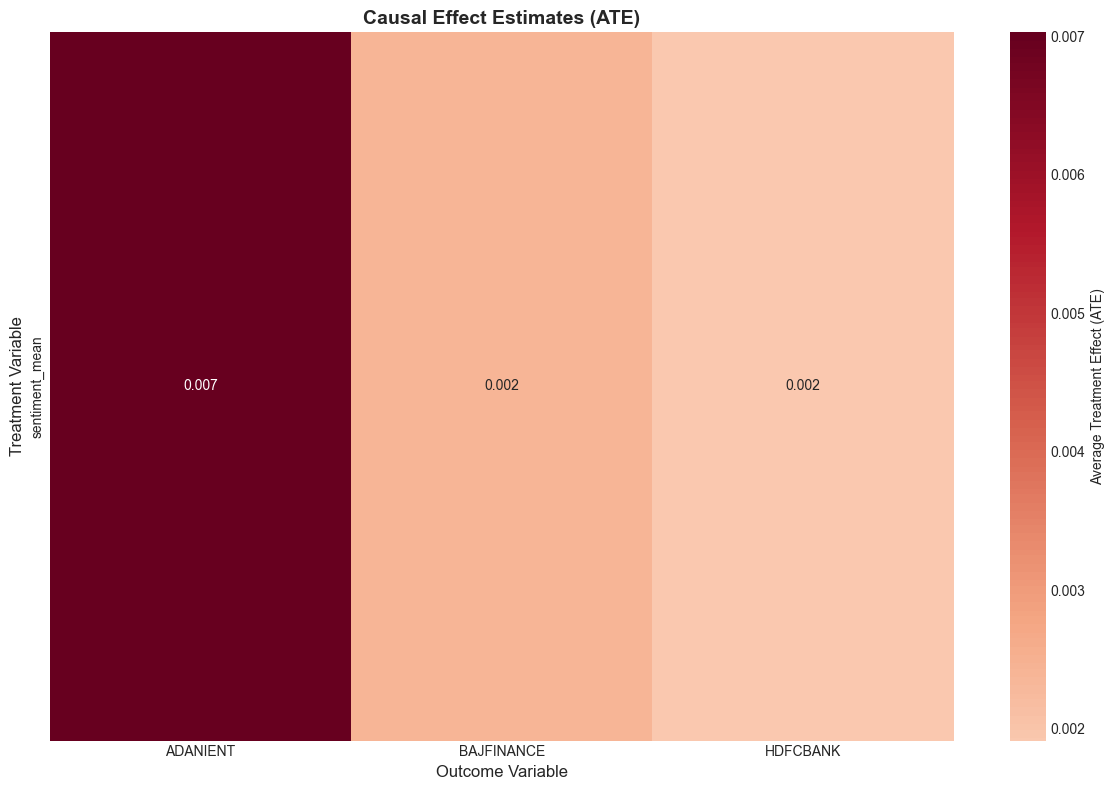


Top 5 Strongest Causal Effects:
  sentiment_mean → ADANIENT: 0.0070
  sentiment_mean → BAJFINANCE: 0.0024
  sentiment_mean → HDFCBANK: 0.0019


In [6]:
if graph is not None and len(effects) > 0:
    fig = viz.plot_causal_effects(
        effects_df,
        title="Causal Effect Estimates (ATE)",
        save_path='../results/figures/causal_effects_heatmap.png'
    )
    plt.show()
    
    # Show top effects
    print("\nTop 5 Strongest Causal Effects:")
    top = effects_df.nlargest(5, 'ate')
    for _, row in top.iterrows():
        print(f"  {row['treatment']} → {row['outcome']}: {row['ate']:.4f}")

## 5. Compare: Correlation vs Causation

In [7]:
if graph is not None and len(effects) > 0:
    print("\n=== Correlation vs Causation ===")
    
    for _, row in effects_df.iterrows():
        treatment = row['treatment']
        outcome = row['outcome']
        
        if treatment in data.columns and outcome in data.columns:
            corr = data[treatment].corr(data[outcome])
            caus = row['ate']
            
            print(f"\n{treatment} → {outcome}:")
            print(f"  Correlation: {corr:.4f}")
            print(f"  Causal Effect (ATE): {caus:.4f}")
            print(f"  Difference: {abs(corr - caus):.4f}")
            
            if abs(corr - caus) > 0.01:
                print(f"  ⚠ Significant difference! Correlation ≠ Causation")


=== Correlation vs Causation ===

sentiment_mean → ADANIENT:
  Correlation: 0.0133
  Causal Effect (ATE): 0.0070
  Difference: 0.0063

sentiment_mean → BAJFINANCE:
  Correlation: 0.0033
  Causal Effect (ATE): 0.0024
  Difference: 0.0009

sentiment_mean → HDFCBANK:
  Correlation: -0.0222
  Causal Effect (ATE): 0.0019
  Difference: 0.0241
  ⚠ Significant difference! Correlation ≠ Causation


## 6. Estimate Multiple Effects

In [8]:
if graph is not None:
    # Define multiple interventions
    interventions = [
        ('sentiment_mean', 1.0),   # Moderate positive
        ('sentiment_mean', 2.0),   # Strong positive
        ('sentiment_mean', -1.0),  # Moderate negative
    ]
    
    if stock_cols:
        multi_effects = engine.estimate_all_effects(
            interventions,
            stock_cols[:5]
        )
        
        print(f"\nEstimated {len(multi_effects)} causal effects")
        print("\nSample results:")
        print(multi_effects.head(10).to_string())
        
        multi_effects.to_csv('../results/causal_effects_all.csv', index=False)


Estimated 15 causal effects

Sample results:
        treatment     outcome  intervention_value       ate  ci_lower  ci_upper           method
0  sentiment_mean    ADANIENT                 1.0  0.004685 -0.000905  0.011068  custom_backdoor
1  sentiment_mean  BAJFINANCE                 1.0  0.001589 -0.002934  0.006091  custom_backdoor
2  sentiment_mean    HDFCBANK                 1.0  0.001275 -0.000072  0.002801  custom_backdoor
3  sentiment_mean   ICICIBANK                 1.0  0.001259 -0.001082  0.004088  custom_backdoor
4  sentiment_mean        INFY                 1.0 -0.000239 -0.002915  0.002314  custom_backdoor
5  sentiment_mean    ADANIENT                 2.0  0.009370 -0.005867  0.023983  custom_backdoor
6  sentiment_mean  BAJFINANCE                 2.0  0.003179 -0.004387  0.010131  custom_backdoor
7  sentiment_mean    HDFCBANK                 2.0  0.002550 -0.000563  0.006615  custom_backdoor
8  sentiment_mean   ICICIBANK                 2.0  0.002518 -0.002833  0.007357  

## Summary

This notebook demonstrated:
1. Loading causal graphs and data
2. Initializing do-calculus inference engine
3. Estimating causal effects (ATE)
4. Comparing correlation vs causation

**Next**: Run `04_counterfactual.ipynb` for what-if analysis.